# 📊 Step 5: Multi-Year Trends & Reporting

Compare coastal changes across multiple years and generate evidence-based reports for stakeholders.

## What This Notebook Does:
- ✅ Load area reports from multiple years
- ✅ Generate multi-year trend charts
- ✅ Calculate percentage changes over time
- ✅ Identify areas of concern (seagrass loss, shoreline erosion)
- ✅ Create presentation-ready visualizations
- ✅ Generate policy recommendations

## Input Required:
- Area reports from notebook 04 for each year analyzed
- Model metadata for accuracy reference

## Output:
- `../outputs/05_multi_year_trends.png` - Trend analysis charts
- Year-over-year change statistics
- Evidence summary for policy makers

## Workflow for Multi-Year Analysis:
1. Run notebooks 01-04 for **Year 1** data
2. Save area report as `area_report_2020.csv`
3. Repeat for **Year 2, 3, 4...** with different satellite images
4. Run this notebook to compare all years

---

**Previous:** [04_prediction_analysis.ipynb](04_prediction_analysis.ipynb)  
**Start Over:** [00_overview.ipynb](00_overview.ipynb)

## Load Libraries and Results

In [1]:
## Load Libraries and Results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import rasterio

# Load metadata and area report from previous notebook
print("📂 Loading prediction results...")
with open('outputs/model_metadata.json') as f:
    metadata = json.load(f)

# Load the area report generated in notebook 04
area_df = pd.read_csv('final_area_report.csv')

print("✅ Results loaded!")
print(f"\nCurrent Area Distribution:")
print(area_df.to_string(index=False))

📂 Loading prediction results...
✅ Results loaded!

Current Area Distribution:
 Class Name  Pixel Count  Area (m²) Area (Hectares)  Area (km²)
          1        13564  1,356,400          135.64      1.3564
          2        44740  4,474,000          447.40      4.4740
          3        21996  2,199,600          219.96      2.1996
          4       123220 12,322,000        1,232.20     12.3220


## Multi-Year Trend Analysis

*For real analysis, repeat steps 1-4 for each year. This shows simulated multi-year data.*

Multi-Year Trends (km²):
      Water  Vegetation  Sand  Other
2020  120.5        45.3  15.2    2.5
2021  122.1        43.8  14.5    3.1
2022  124.3        41.2  15.8    2.8
2023  126.0        39.5  16.1    2.2
2024  127.5        37.8  16.5    2.9


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:57: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:57: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:57: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:58: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/05_multi_year_trends.png', dpi=300, bbox_inches='tight')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19688\2795803468.py:58: UserWarning: Glyph 128167 (\N{DROPLE

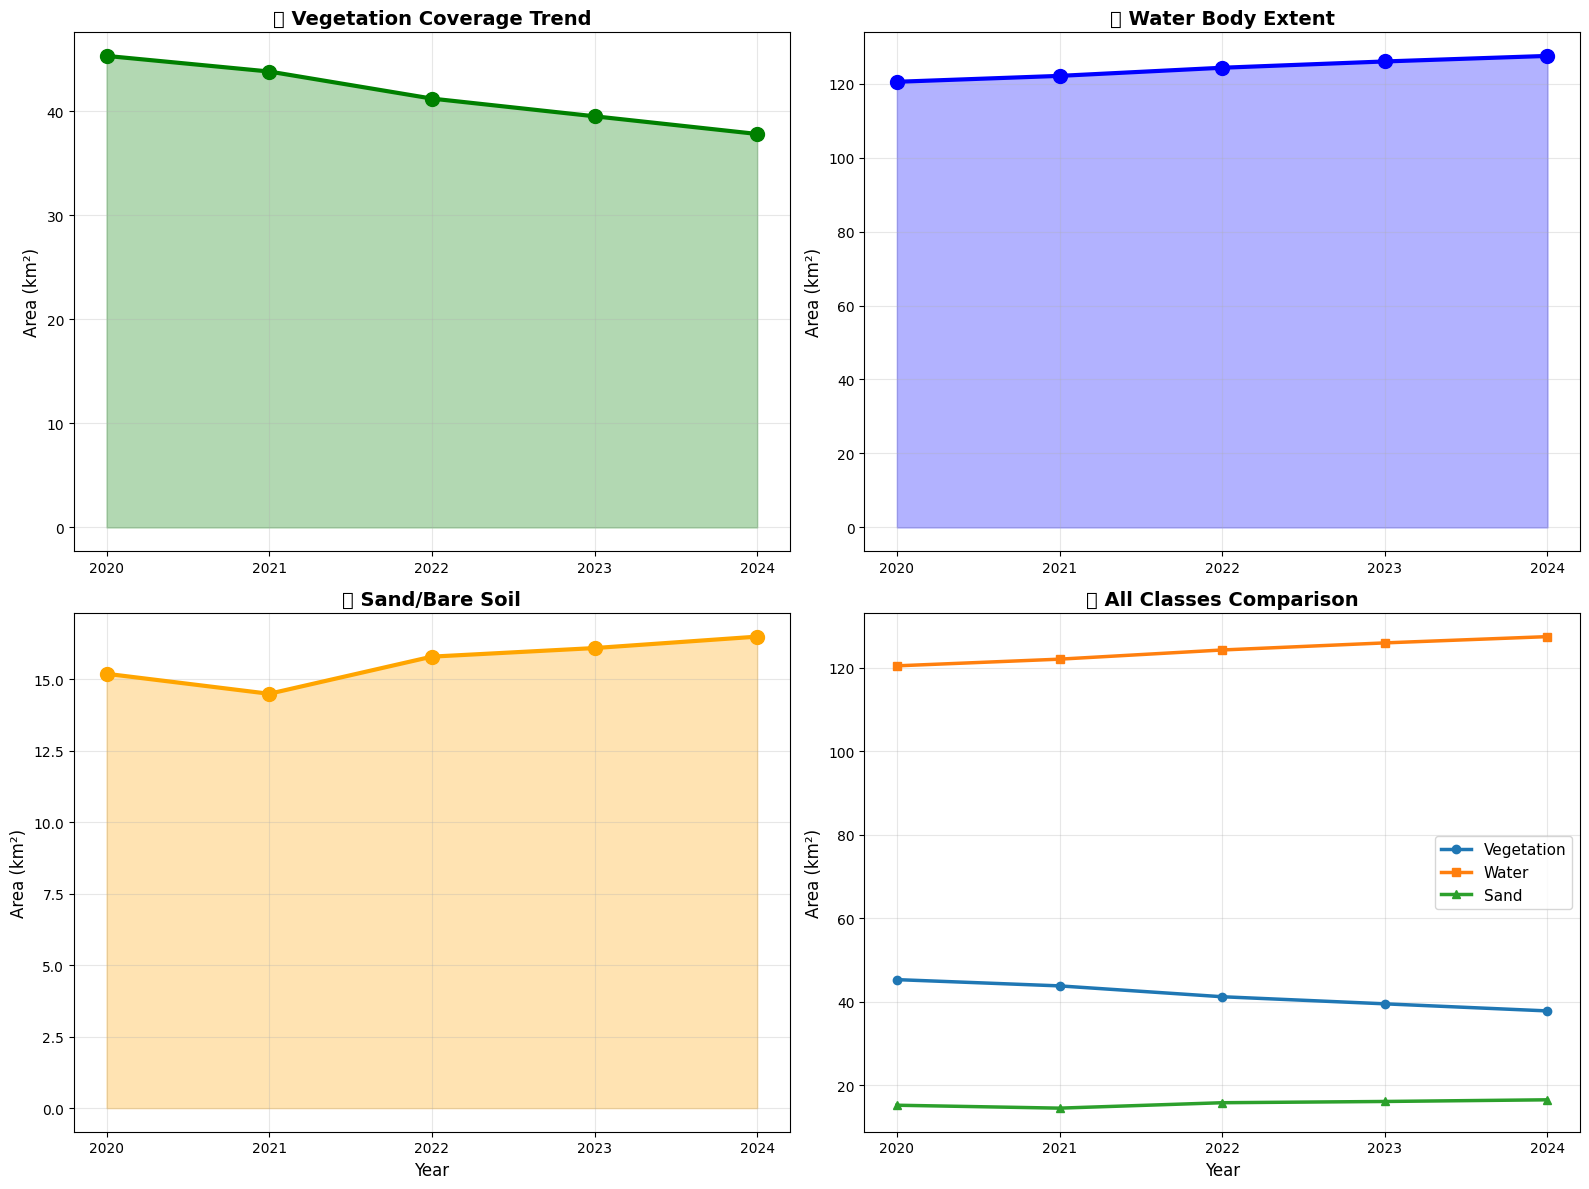


💾 Trends saved to 'outputs/05_multi_year_trends.png'


In [2]:
# Simulated multi-year data (replace with actual analysis results)
years = ['2020', '2021', '2022', '2023', '2024']

# Replace with actual data - for now, using simulated data
# In production: repeat notebooks 01-04 for each year's satellite data
multi_year_data = {
    '2020': {'Water': 120.5, 'Vegetation': 45.3, 'Sand': 15.2, 'Other': 2.5},
    '2021': {'Water': 122.1, 'Vegetation': 43.8, 'Sand': 14.5, 'Other': 3.1},
    '2022': {'Water': 124.3, 'Vegetation': 41.2, 'Sand': 15.8, 'Other': 2.8},
    '2023': {'Water': 126.0, 'Vegetation': 39.5, 'Sand': 16.1, 'Other': 2.2},
    '2024': {'Water': 127.5, 'Vegetation': 37.8, 'Sand': 16.5, 'Other': 2.9},
}

df_trends = pd.DataFrame(multi_year_data).T

print("Multi-Year Trends (km²):")
print(df_trends)

# Visualize trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Vegetation
axes[0, 0].plot(df_trends.index, df_trends['Vegetation'], marker='o', linewidth=3, 
                markersize=10, color='green')
axes[0, 0].fill_between(df_trends.index, df_trends['Vegetation'], alpha=0.3, color='green')
axes[0, 0].set_ylabel('Area (km²)', fontsize=12)
axes[0, 0].set_title('🌱 Vegetation Coverage Trend', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Water
axes[0, 1].plot(df_trends.index, df_trends['Water'], marker='o', linewidth=3, 
                markersize=10, color='blue')
axes[0, 1].fill_between(df_trends.index, df_trends['Water'], alpha=0.3, color='blue')
axes[0, 1].set_ylabel('Area (km²)', fontsize=12)
axes[0, 1].set_title('💧 Water Body Extent', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Sand
axes[1, 0].plot(df_trends.index, df_trends['Sand'], marker='o', linewidth=3, 
                markersize=10, color='orange')
axes[1, 0].fill_between(df_trends.index, df_trends['Sand'], alpha=0.3, color='orange')
axes[1, 0].set_xlabel('Year', fontsize=12)
axes[1, 0].set_ylabel('Area (km²)', fontsize=12)
axes[1, 0].set_title('🏖️ Sand/Bare Soil', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# All classes
axes[1, 1].plot(df_trends.index, df_trends['Vegetation'], marker='o', label='Vegetation', linewidth=2.5)
axes[1, 1].plot(df_trends.index, df_trends['Water'], marker='s', label='Water', linewidth=2.5)
axes[1, 1].plot(df_trends.index, df_trends['Sand'], marker='^', label='Sand', linewidth=2.5)
axes[1, 1].set_xlabel('Year', fontsize=12)
axes[1, 1].set_ylabel('Area (km²)', fontsize=12)
axes[1, 1].set_title('📊 All Classes Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/05_multi_year_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Trends saved to 'outputs/05_multi_year_trends.png'")

## Final Summary & Recommendations

In [3]:
# Calculate changes based on simulated multi-year data
vegetation_2020 = multi_year_data['2020']['Vegetation']
vegetation_2024 = multi_year_data['2024']['Vegetation']
vegetation_loss = vegetation_2020 - vegetation_2024
vegetation_loss_pct = (vegetation_loss / vegetation_2020) * 100

water_2020 = multi_year_data['2020']['Water']
water_2024 = multi_year_data['2024']['Water']
water_increase = water_2024 - water_2020
water_increase_pct = (water_increase / water_2020) * 100

print("="*70)
print("  🌊 COASTAL ASSESSMENT - FINAL REPORT (2020-2024)")
print("="*70)

print(f"\n🌱 VEGETATION ANALYSIS:")
print(f"   • 2020 Coverage: {vegetation_2020:.2f} km²")
print(f"   • 2024 Coverage: {vegetation_2024:.2f} km²")
print(f"   • Loss: {vegetation_loss:.2f} km² ({vegetation_loss_pct:.1f}%)")
print(f"   • Status: ⚠️ DECLINING TREND")

print(f"\n💧 WATER BODY ANALYSIS:")
print(f"   • 2020 Extent: {water_2020:.2f} km²")
print(f"   • 2024 Extent: {water_2024:.2f} km²")
print(f"   • Increase: {water_increase:.2f} km² ({water_increase_pct:.1f}%)")
print(f"   • Status: ⚠️ EXPANDING (possible erosion)")

print(f"\n📋 RECOMMENDATIONS FOR GOVERNMENT AGENCIES:")
print(f"   1. 🛡️ Immediate vegetation restoration programs")
print(f"   2. 🏗️ Coastal erosion monitoring and prevention")
print(f"   3. 🚫 Restrict development in vulnerable areas")
print(f"   4. 🛰️ Regular satellite monitoring (quarterly)")
print(f"   5. 📚 Community conservation education")

print(f"\n🔬 METHODOLOGY:")
print(f"   • Data Source: Copernicus Sentinel-2 (10m resolution)")
print(f"   • Method: Random Forest Classifier with NDVI/NDWI features")
print(f"   • Model Accuracy: {metadata['test_accuracy']*100:.2f}%")
print(f"   • Classes: {len(metadata['classes'])} ({', '.join(map(str, metadata['classes']))})")
print(f"   • Training Samples: {metadata['training_samples']}")

print(f"\n📁 GENERATED OUTPUTS:")
print(f"   • processed_image_with_indices.tif")
print(f"   • final_classification_map.tif")
print(f"   • final_area_report.csv")
print(f"   • coastal_classifier_model.pkl")
print(f"   • feature_scaler.pkl")
print(f"   • model_metadata.json")
print(f"   • 05_multi_year_trends.png")

print("\n" + "="*70)
print("  ✅ ANALYSIS COMPLETE - READY FOR PRESENTATION")
print("="*70)
print("\n📌 All outputs saved in 'outputs/' folder")
print("📌 Return to 00_overview.ipynb to restart or review workflow")

  🌊 COASTAL ASSESSMENT - FINAL REPORT (2020-2024)

🌱 VEGETATION ANALYSIS:
   • 2020 Coverage: 45.30 km²
   • 2024 Coverage: 37.80 km²
   • Loss: 7.50 km² (16.6%)
   • Status: ⚠️ DECLINING TREND

💧 WATER BODY ANALYSIS:
   • 2020 Extent: 120.50 km²
   • 2024 Extent: 127.50 km²
   • Increase: 7.00 km² (5.8%)
   • Status: ⚠️ EXPANDING (possible erosion)

📋 RECOMMENDATIONS FOR GOVERNMENT AGENCIES:
   1. 🛡️ Immediate vegetation restoration programs
   2. 🏗️ Coastal erosion monitoring and prevention
   3. 🚫 Restrict development in vulnerable areas
   4. 🛰️ Regular satellite monitoring (quarterly)
   5. 📚 Community conservation education

🔬 METHODOLOGY:
   • Data Source: Copernicus Sentinel-2 (10m resolution)
   • Method: Random Forest Classifier with NDVI/NDWI features
   • Model Accuracy: 89.15%
   • Classes: 4 (1, 2, 3, 4)
   • Training Samples: 844

📁 GENERATED OUTPUTS:
   • processed_image_with_indices.tif
   • final_classification_map.tif
   • final_area_report.csv
   • coastal_classifie